In [1]:
# ===========================
# 1. Imports
# ===========================
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
from PIL import Image
import torch
from torch import nn
from torchvision import models, transforms
import numpy as np
from tqdm import tqdm

# ===========================
# 2. Dataset Setup
# ===========================
dataset_path = "/content/drive/MyDrive/ML1 Final Project/Cleaned Data"
classes = ["real", "fake"] # real 0 fake 1
max_per_class = 5000  # limit per class

# Preprocessing transforms for ResNet18
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [4]:

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# Load the model (e.g., ResNet18)
resnet = models.resnet18(pretrained=True)

# Set to evaluation mode
resnet.eval()

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = resnet.to(device)

# Optional: Remove the last classification layer to get embeddings
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1]))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 454MB/s]


In [1]:
# ===========================
# 4. Extract embeddings with batching
# ===========================
import torch
from tqdm import tqdm
import numpy as np
from PIL import Image

X = []
y = []
image_paths = []

batch_size = 32  # process 32 images at a time

# Prepare list of images per class with random sampling
images_per_class = {}
for label_idx, label in enumerate(classes):
    folder = os.path.join(dataset_path, label)
    all_images = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_images)
    images_per_class[label] = all_images[:max_per_class]

# Flatten list with labels for easier batching
all_samples = []
for label_idx, label in enumerate(classes):
    folder = os.path.join(dataset_path, label)
    for img_name in images_per_class[label]:
        all_samples.append((os.path.join(folder, img_name), label_idx))

total_images = len(all_samples)
pbar = tqdm(total=total_images, desc="Extracting embeddings")

# Process in batches
for i in range(0, total_images, batch_size):
    batch = all_samples[i:i+batch_size]

    imgs = []
    batch_labels = []
    batch_paths = []

    for img_path, label_idx in batch:
        img = Image.open(img_path).convert('RGB')
        img_tensor = preprocess(img)
        imgs.append(img_tensor)
        batch_labels.append(label_idx)
        batch_paths.append(img_path)

    batch_tensor = torch.stack(imgs).to(device)

    with torch.no_grad():
        embeddings = resnet(batch_tensor)  # shape: [batch, 512, 1, 1] for ResNet18
        embeddings = embeddings.squeeze(-1).squeeze(-1).cpu().numpy()  # [batch, 512]

    X.append(embeddings)
    y.extend(batch_labels)
    image_paths.extend(batch_paths)

    pbar.update(len(batch))

pbar.close()

# Convert X to single array
X = np.vstack(X)
y = np.array(y)
print("Embeddings shape:", X.shape)

NameError: name 'classes' is not defined

In [6]:
# dhawal test

# ===========================
# 4. Extract embeddings with batching - Optimized
# ===========================
import torch
from tqdm import tqdm
import numpy as np
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
import os

# Optimization 1: Enable cuDNN benchmark for faster fixed-size input processing
torch.backends.cudnn.benchmark = True

X = []
y = []
image_paths = []

# Optimization 2: Increase batch size for better GPU utilization (ResNet18 is small, can handle 128+)
batch_size = 128
max_per_class = 50_000

# Prepare list of images per class with random sampling
images_per_class = {}
for label_idx, label in enumerate(classes):
    folder = os.path.join(dataset_path, label)
    all_images = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(all_images)
    images_per_class[label] = all_images[:max_per_class]

# Flatten list with labels for easier batching
all_samples = []
for label_idx, label in enumerate(classes):
    folder = os.path.join(dataset_path, label)
    for img_name in images_per_class[label]:
        all_samples.append((os.path.join(folder, img_name), label_idx))

total_images = len(all_samples)
pbar = tqdm(total=total_images, desc="Extracting embeddings")

def process_image(sample):
    """Helper function to load and preprocess a single image."""
    img_path, label_idx = sample
    try:
        img = Image.open(img_path).convert('RGB')
        img_tensor = preprocess(img)
        return img_tensor, label_idx, img_path
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

# Optimization 3: Use Half Precision (FP16) for faster inference if on CUDA
if device.type == 'cuda':
    resnet.half()

# Process in batches
# Optimization 4: Use requested 48 workers
with ThreadPoolExecutor(max_workers=48) as executor:
    for i in range(0, total_images, batch_size):
        batch = all_samples[i:i+batch_size]

        # Submit tasks for the current batch
        results = list(executor.map(process_image, batch))

        # Filter out any failed loads (None results)
        results = [r for r in results if r is not None]

        if not results:
            continue

        # Unzip the results
        batch_imgs, batch_labels, batch_paths = zip(*results)

        # Stack tensors
        batch_tensor = torch.stack(batch_imgs)

        # Move to device and cast to half if on GPU
        if device.type == 'cuda':
            batch_tensor = batch_tensor.half().to(device, non_blocking=True)
        else:
            batch_tensor = batch_tensor.to(device)

        with torch.no_grad():
            embeddings = resnet(batch_tensor)  # shape: [batch, 512, 1, 1] for ResNet18
            # Cast back to float32 before numpy conversion for stability
            embeddings = embeddings.squeeze(-1).squeeze(-1).float().cpu().numpy()

        X.append(embeddings)
        y.extend(batch_labels)
        image_paths.extend(batch_paths)

        pbar.update(len(batch))

pbar.close()

# Revert model to float just in case it's used elsewhere later
if device.type == 'cuda':
    resnet.float()

# Convert X to single array
if X:
    X = np.vstack(X)
    y = np.array(y)
    print("Embeddings shape:", X.shape)
else:
    print("No embeddings extracted.")

Extracting embeddings:   1%|▏         | 128/10000 [00:20<09:13, 17.84it/s]

KeyboardInterrupt: 

In [9]:
import pandas as pd

# Convert embeddings to DataFrame
embedding_dim = X.shape[1]
embedding_cols = [f"emb_{i}" for i in range(embedding_dim)]

df = pd.DataFrame(X, columns=embedding_cols)
df["label"] = y
df["image_path"] = image_paths

print(df.head())
print(df.shape)


output_path = "/content/drive/MyDrive/ML1 Final Project/resnet18_dhawal_test_parquet.parquet"
df.to_parquet(output_path)

print(f"Saved embeddings to {output_path}")



      emb_0     emb_1     emb_2     emb_3     emb_4     emb_5     emb_6  \
0  0.500000  0.351074  0.249268  0.503906  0.015007  0.098267  0.261230   
1  0.167358  2.333984  1.515625  0.691895  0.929199  0.602051  1.002930   
2  0.480225  0.741699  1.546875  0.882324  0.126587  0.155518  0.470703   
3  0.658203  1.466797  0.993164  0.449707  0.956543  0.053253  1.465820   
4  0.471924  0.398193  0.838867  0.593262  0.583984  0.048859  1.254883   

      emb_7     emb_8     emb_9  ...   emb_504   emb_505   emb_506   emb_507  \
0  1.358398  0.134888  0.158936  ...  1.792969  1.004883  3.052734  0.359863   
1  0.500000  0.792969  0.017700  ...  0.920898  1.612305  0.922852  1.461914   
2  0.305664  0.536621  0.534180  ...  0.541504  0.806641  3.310547  0.931152   
3  0.966309  0.431152  0.230103  ...  0.651855  1.098633  2.099609  0.686523   
4  0.325928  0.718262  0.337158  ...  0.740723  0.747070  3.367188  1.428711   

    emb_508   emb_509   emb_510   emb_511  label  \
0  0.399658  0.6

In [ ]:
import pandas as pd

# Convert embeddings to DataFrame
embedding_dim = X.shape[1]
embedding_cols = [f"emb_{i}" for i in range(embedding_dim)]

df = pd.DataFrame(X, columns=embedding_cols)
df["label"] = y
df["image_path"] = image_paths

print(df.head())
print(df.shape)

      emb_0     emb_1     emb_2     emb_3     emb_4     emb_5     emb_6  \
0  1.055535  0.133661  0.897673  1.097033  0.601506  0.417272  2.309882   
1  0.000000  0.237881  1.509098  0.640314  0.039206  0.076827  0.239381   
2  0.151744  0.488820  1.103299  0.309695  0.140026  0.042446  0.137338   
3  0.974255  0.603028  0.577853  0.156421  0.176245  0.148384  0.943647   
4  0.002800  1.001909  0.561875  0.373724  0.331607  0.234691  0.156683   

      emb_7     emb_8     emb_9  ...   emb_504   emb_505   emb_506   emb_507  \
0  0.329897  0.118694  0.579910  ...  1.224009  1.097021  1.693049  1.875436   
1  0.611422  0.049045  0.082517  ...  0.618985  0.125834  3.581824  0.120598   
2  0.540814  0.148879  0.100807  ...  0.235187  0.232520  2.171654  0.823837   
3  0.907221  0.185337  0.405730  ...  0.771660  1.937275  3.520219  1.859427   
4  0.920501  0.491701  0.327045  ...  1.206913  1.085480  2.976072  0.836052   

    emb_508   emb_509   emb_510   emb_511  label  \
0  1.144806  0.9

In [ ]:
output_path = "/content/drive/MyDrive/ML1 Final Project/cleaned_data_resnet18_face_embeddings.csv"
df.to_csv(output_path)

print(f"Saved embeddings to {output_path}")

Saved embeddings to /content/drive/MyDrive/ML1 Final Project/cleaned_data_resnet18_face_embeddings.csv


In [ ]:
import os
print(os.listdir('.'))

['.config', 'drive', 'sample_data']


## Check output

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/ML1 Final Project/cleaned_data_resnet18_face_embeddings.csv")
df.head(5)


,Unnamed: 0,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511,label,image_path
0,0,1.055535,0.133661,0.897673,1.097033,0.601506,0.417272,2.309882,0.329897,0.118694,...,1.224009,1.097021,1.693049,1.875436,1.144806,0.955699,0.652855,1.850326,0,/content/drive/MyDrive/ML1 Final Project/Clean...
1,1,0.000000,0.237881,1.509098,0.640314,0.039206,0.076827,0.239381,0.611422,0.049045,...,0.618985,0.125834,3.581824,0.120598,0.085368,0.537261,1.416819,0.152021,0,/content/drive/MyDrive/ML1 Final Project/Clean...
2,2,0.151744,0.488820,1.103299,0.309695,0.140026,0.042446,0.137338,0.540814,0.148879,...,0.235187,0.232520,2.171654,0.823837,0.219310,2.118355,1.352215,0.097055,0,/content/drive/MyDrive/ML1 Final Project/Clean...
3,3,0.974255,0.603028,0.577853,0.156421,0.176245,0.148384,0.943647,0.907221,0.185337,...,0.771660,1.937275,3.520219,1.859427,0.035255,0.556134,0.628942,1.056855,0,/content/drive/MyDrive/ML1 Final Project/Clean...
4,4,0.002800,1.001909,0.561875,0.373724,0.331607,0.234691,0.156683,0.920501,0.491701,...,1.206913,1.085480,2.976072,0.836052,0.151808,0.919974,0.694544,0.736744,0,/content/drive/MyDrive/ML1 Final Project/Clean...


In [ ]:
df.shape

(10000, 515)

In [ ]:
y = df["label"].values
X = df.drop(["label", "image_path", "Unnamed: 0"], axis=1).values
image_paths = df["image_path"].values

## Train Random Forest

Train PCA shape: (8000, 200)
Test PCA shape: (2000, 200)
Accuracy: 0.714
F1-score: 0.6846747519294377

Classification Report:
               precision    recall  f1-score   support

        real       0.68      0.81      0.74      1000
        fake       0.76      0.62      0.68      1000

    accuracy                           0.71      2000
   macro avg       0.72      0.71      0.71      2000
weighted avg       0.72      0.71      0.71      2000



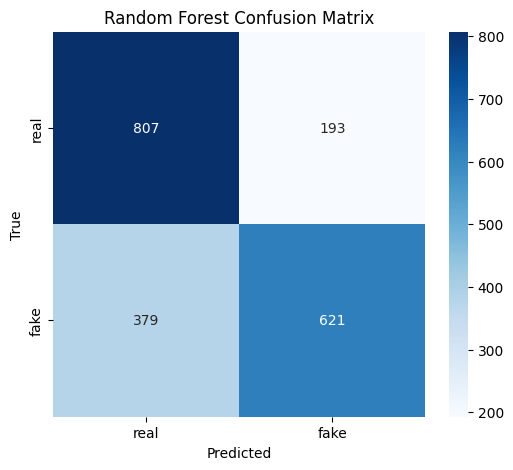

TP examples indices: [ 2  7 10 14]
TN examples indices: [ 3  9 11 12]
FP examples indices: [ 1  4  8 13]
FN examples indices: [ 0  5  6 16]
True Positive


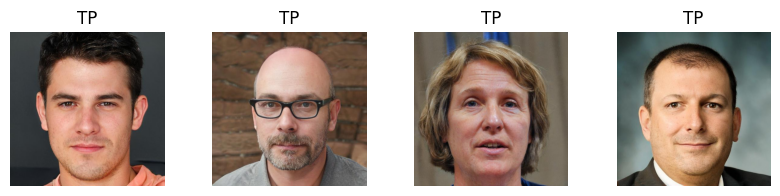

True Negative


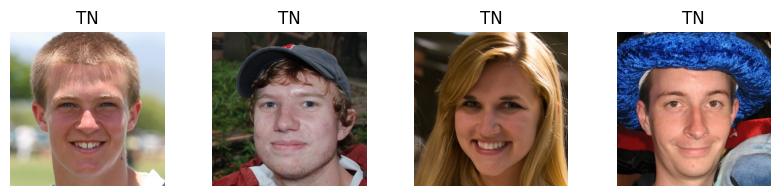

False Positive


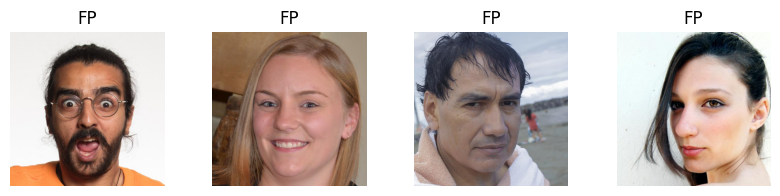

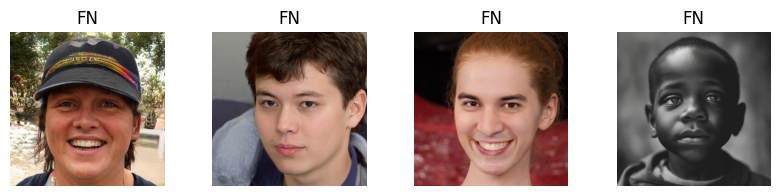

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ===========================
# 5. Train/test split (before PCA!)
# ===========================
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, image_paths, test_size=0.2, random_state=0, stratify=y
)

# ===========================
# 6. PCA for dimensionality reduction (fit on train only)
# ===========================
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)  # <-- only transform test set

print("Train PCA shape:", X_train_pca.shape)
print("Test PCA shape:", X_test_pca.shape)

# ===========================
# 7. Random Forest Training
# ===========================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pca, y_train)
y_pred = rf.predict(X_test_pca)

# ===========================
# 8. Evaluation
# ===========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Confusion Matrix")
plt.show()

# ===========================
# 9. Identify TP, TN, FP, FN indices
# ===========================
TP_idx = np.where((y_test == 1) & (y_pred == 1))[0]
TN_idx = np.where((y_test == 0) & (y_pred == 0))[0]
FP_idx = np.where((y_test == 0) & (y_pred == 1))[0]
FN_idx = np.where((y_test == 1) & (y_pred == 0))[0]

# Pick up to 4 examples from each
tp_examples = TP_idx[:4]
tn_examples = TN_idx[:4]
fp_examples = FP_idx[:4]
fn_examples = FN_idx[:4]

print("TP examples indices:", tp_examples)
print("TN examples indices:", tn_examples)
print("FP examples indices:", fp_examples)
print("FN examples indices:", fn_examples)

# ===========================
# 10. Display example images
# ===========================
def show_examples(indices, paths, title):
    plt.figure(figsize=(10,2))
    for i, idx in enumerate(indices):
        img_path = paths[idx]
        img = Image.open(img_path).convert('RGB')
        plt.subplot(1, len(indices), i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
    plt.show()

print("True Positive")
show_examples(tp_examples, paths_test, "TP")
print("True Negative")
show_examples(tn_examples, paths_test, "TN")
print("False Positive")
show_examples(fp_examples, paths_test, "FP")
show_examples(fn_examples, paths_test, "FN")
